In [5]:
import pandas as pd
import numpy as np
from data.preparing_data import *
from catboost import CatBoostClassifier, Pool
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import json
from pathlib import Path

In [29]:
df = pd.read_parquet("data/history_data.parquet")

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230668 entries, 0 to 230667
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   timestamp  230668 non-null  datetime64[ns]
 1   open       230668 non-null  float64       
 2   high       230668 non-null  float64       
 3   low        230668 non-null  float64       
 4   close      230668 non-null  float64       
 5   volume     230668 non-null  float64       
 6   symbol     230668 non-null  object        
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 12.3+ MB


In [31]:
def calculate_max_drawdown(series):
    rolling_max = series.cummax()
    drawdown = (series - rolling_max) / rolling_max
    return drawdown.cummin()

df = df.sort_values(["symbol", "timestamp"])
df["ret_1"] = df.groupby("symbol")["close"].pct_change()
closed = df.groupby("symbol")["close"]
windows = (1,7,20,50)
for window in windows:
    
    df[f"ret_{window}"] = closed.pct_change(window)

    df[f"vol_{window}"] = (
        df.groupby("symbol")["ret_1"]
        .rolling(window)
        .std()
        .reset_index(level=0, drop=True)
    )

    df[f"volume_z_{window}"] = (
        df.groupby("symbol")["volume"]
        .transform(lambda x: (x - x.rolling(window).mean()) / (x.rolling(window).std() + 1e-12))
    )

    df[f"price_z_{window}"] = (
        df.groupby("symbol")["close"]
        .transform(lambda x: (x - x.rolling(window).mean()) / (x.rolling(window).std() + 1e-12))
    )
    df[f"high_{window}"] = df.groupby("symbol")["high"].transform(
    lambda x: x.rolling(window).max().shift(1)
    )

df["net_return"] = closed.transform(lambda x: (x / x.iloc[0]) - 1)
df["max_drawdown"] = closed.transform(calculate_max_drawdown)

future_return = df.groupby("symbol")["close"].transform(
lambda x: x.pct_change(3).shift(-3)
)

df["candle_range"] = (df["high"] - df["low"]) / df["close"]
df["body_size"] = abs(df["close"] - df["open"]) / df["open"]

df["signal_long"] = (
    (df["close"] > df["high_20"]) &
    (df["volume_z_20"] > 1)
).astype(int)

# df["target_good_trade"] = (future_return > 0.02).astype(int)


df["candle_range"] = (df["high"] - df["low"]) / df["close"]
df["body_size"] = abs(df["close"] - df["open"]) / df["open"]

btc = df[df["symbol"] == "BTCUSDT"][["timestamp", "ret_1", "ret_7", "ret_20", "ret_50", "vol_20", "close"]].copy()

btc = btc.rename(columns={
    "ret_1": "btc_ret_1",
    "ret_7": "btc_ret_7",
    "ret_20": "btc_ret_20",
    "ret_50": "btc_ret_50",
    "vol_20": "btc_vol_20",
    "close": "btc_close"
})

btc["btc_ma_50"] = btc["btc_close"].rolling(50).mean()
btc["btc_ma_200"] = btc["btc_close"].rolling(200).mean()
btc["btc_trend_up"] = (btc["btc_ma_50"] > btc["btc_ma_200"]).astype(int)
btc["btc_rolling_max_100"] = btc["btc_close"].rolling(100).max()
btc["btc_drawdown_100"] = btc["btc_close"] / btc["btc_rolling_max_100"] - 1
btc["btc_vol_50"] = btc["btc_ret_1"].rolling(50).std()
btc["btc_vol_ratio"] = btc["btc_vol_20"] / (btc["btc_vol_50"] + 1e-12)


df = df.merge(btc, on="timestamp", how="left")

df["rel_ret_7"] = df["ret_7"] - df["btc_ret_7"]
df["rel_ret_20"] = df["ret_20"] - df["btc_ret_20"]
df["rel_ret_50"] = df["ret_50"] - df["btc_ret_50"]

df["prev_close"] = df.groupby("symbol")["close"].shift(1)
df["true_range"] = np.maximum.reduce([
    df["high"] - df["low"],
    abs(df["high"] - df["prev_close"]),
    abs(df["low"] - df["prev_close"]),
])
df["atr_14"] = (
    df.groupby("symbol")["true_range"]
    .transform(lambda x: x.rolling(14).mean())
)
df["atr_14_pct"] = df["atr_14"] / df["close"]
df["high_50"] = df.groupby("symbol")["high"].transform(
    lambda x: x.rolling(50).max().shift(1)
)
df["low_50"] = df.groupby("symbol")["low"].transform(
    lambda x: x.rolling(50).min().shift(1)
)
df["distance_to_high_50"] = df["close"] / df["high_50"] - 1
df["distance_to_low_50"] = df["close"] / df["low_50"] - 1

df["vol_ratio_7_50"] = df["vol_7"] / (df["vol_50"] + 1e-12)
df["vol_ratio_20_50"] = df["vol_20"] / (df["vol_50"] + 1e-12)
df["dollar_volume"] = df["close"] * df["volume"]
df["dollar_volume_z_50"] = df.groupby("symbol")["dollar_volume"].transform(
    lambda x: (x - x.rolling(50).mean()) / (x.rolling(50).std() + 1e-12)
)
df["log_dollar_volume"] = np.log1p(df["dollar_volume"])
market_ret = (
    df.groupby("timestamp")["ret_1"]
    .median()
    .reset_index()
    .rename(columns={"ret_1": "market_ret_1"})
)
df = df.merge(market_ret, on="timestamp", how="left")
df["rel_market_ret_1"] = df["ret_1"] - df["market_ret_1"]
df["rel_btc_market_spread"] = df["rel_ret_7"] - df["rel_market_ret_1"]
df["hour"] = df["timestamp"].dt.hour
df["weekday"] = df["timestamp"].dt.weekday


delta = df.groupby("symbol")["close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.groupby(df["symbol"]).transform(lambda x: x.rolling(14).mean())
avg_loss = loss.groupby(df["symbol"]).transform(lambda x: x.rolling(14).mean())

rs = avg_gain / (avg_loss + 1e-12)

df["rsi_14"] = 100 - (100 / (1 + rs))

df["signal_breakout"] = (
    (df["close"] > df["high_20"]) &
    (df["volume_z_20"] > 0.5)
).astype(int)

df["signal_mean_reversion"] = (
    (df["rsi_14"] < 35) &
    (df["price_z_20"] < -1.0)
).astype(int)
df = df.fillna(0)
display(df)

,timestamp,open,high,low,close,volume,symbol,ret_1,vol_1,volume_z_1,...,dollar_volume_z_50,log_dollar_volume,market_ret_1,rel_market_ret_1,rel_btc_market_spread,hour,weekday,rsi_14,signal_breakout,signal_mean_reversion
0,2025-12-09 18:00:00,188.9900,197.2300,187.7000,196.3700,18207.878,AAVEUSDT,0.000000,0.0,0.0,...,0.000000,15.089611,0.000000,0.000000,0.000000,18,1,0.000000,0,0
1,2025-12-09 19:00:00,196.3800,204.9300,196.3800,204.6500,26802.688,AAVEUSDT,0.042165,0.0,0.0,...,0.000000,15.517559,0.026417,0.015748,0.000000,19,1,0.000000,0,0
2,2025-12-09 20:00:00,204.6600,206.3200,202.9600,205.0900,17590.349,AAVEUSDT,0.002150,0.0,0.0,...,0.000000,15.098555,-0.003828,0.005978,0.000000,20,1,0.000000,0,0
3,2025-12-09 21:00:00,205.1000,205.8500,203.5500,204.3500,7925.111,AAVEUSDT,-0.003608,0.0,0.0,...,0.000000,14.297626,-0.001684,-0.001924,0.000000,21,1,0.000000,0,0
4,2025-12-09 22:00:00,204.3600,205.9400,203.2300,204.9600,5955.177,AAVEUSDT,0.002985,0.0,0.0,...,0.000000,14.014832,-0.002807,0.005792,0.000000,22,1,0.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230663,2026-07-11 09:00:00,1.1065,1.1093,1.1052,1.1076,1065697.200,XRPUSDT,0.000994,0.0,0.0,...,-0.704379,13.981336,-0.000036,0.001030,0.000791,9,5,54.480287,0,0
230664,2026-07-11 10:00:00,1.1076,1.1093,1.1072,1.1077,739388.000,XRPUSDT,0.000090,0.0,0.0,...,-0.919250,13.615865,-0.000015,0.000105,0.001471,10,5,64.556962,0,0
230665,2026-07-11 11:00:00,1.1076,1.1089,1.1058,1.1086,997998.100,XRPUSDT,0.000812,0.0,0.0,...,-0.701705,13.916606,0.001757,-0.000945,0.002069,11,5,69.230769,0,0
230666,2026-07-11 12:00:00,1.1085,1.1110,1.1064,1.1065,769807.600,XRPUSDT,-0.001894,0.0,0.0,...,-0.846592,13.655099,-0.000697,-0.001197,0.001233,12,5,53.500000,0,0


In [32]:
horizon = 3
fee = 0.001

df["entry_price"] = df.groupby("symbol")["open"].shift(-1)
df["exit_price"] = df.groupby("symbol")["close"].shift(-horizon)

future_lows = []

for i in range(1, horizon + 1):
    future_lows.append(df.groupby("symbol")["low"].shift(-i))

df["future_min_low"] = pd.concat(future_lows, axis=1).min(axis=1)

df["net_return"] = df["exit_price"] / df["entry_price"] - 1 - 2 * fee
df["max_drawdown"] = df["future_min_low"] / df["entry_price"] - 1

df["target_good_trade"] = (
    (df["net_return"] > 0.002) &
    (df["max_drawdown"] > -0.015)
).astype(int)

In [33]:
df = df.fillna(0)
df


,timestamp,open,high,low,close,volume,symbol,ret_1,vol_1,volume_z_1,...,rel_btc_market_spread,hour,weekday,rsi_14,signal_breakout,signal_mean_reversion,entry_price,exit_price,future_min_low,target_good_trade
0,2025-12-09 18:00:00,188.9900,197.2300,187.7000,196.3700,18207.878,AAVEUSDT,0.000000,0.0,0.0,...,0.000000,18,1,0.000000,0,0,196.3800,204.3500,196.3800,1
1,2025-12-09 19:00:00,196.3800,204.9300,196.3800,204.6500,26802.688,AAVEUSDT,0.042165,0.0,0.0,...,0.000000,19,1,0.000000,0,0,204.6600,204.9600,202.9600,0
2,2025-12-09 20:00:00,204.6600,206.3200,202.9600,205.0900,17590.349,AAVEUSDT,0.002150,0.0,0.0,...,0.000000,20,1,0.000000,0,0,205.1000,203.3200,201.0500,0
3,2025-12-09 21:00:00,205.1000,205.8500,203.5500,204.3500,7925.111,AAVEUSDT,-0.003608,0.0,0.0,...,0.000000,21,1,0.000000,0,0,204.3600,201.9400,201.0500,0
4,2025-12-09 22:00:00,204.3600,205.9400,203.2300,204.9600,5955.177,AAVEUSDT,0.002985,0.0,0.0,...,0.000000,22,1,0.000000,0,0,204.9500,205.1900,201.0500,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230663,2026-07-11 09:00:00,1.1065,1.1093,1.1052,1.1076,1065697.200,XRPUSDT,0.000994,0.0,0.0,...,0.000791,9,5,54.480287,0,0,1.1076,1.1065,1.1058,0
230664,2026-07-11 10:00:00,1.1076,1.1093,1.1072,1.1077,739388.000,XRPUSDT,0.000090,0.0,0.0,...,0.001471,10,5,64.556962,0,0,1.1076,1.1073,1.1058,0
230665,2026-07-11 11:00:00,1.1076,1.1089,1.1058,1.1086,997998.100,XRPUSDT,0.000812,0.0,0.0,...,0.002069,11,5,69.230769,0,0,1.1085,0.0000,1.1061,0
230666,2026-07-11 12:00:00,1.1085,1.1110,1.1064,1.1065,769807.600,XRPUSDT,-0.001894,0.0,0.0,...,0.001233,12,5,53.500000,0,0,1.1065,0.0000,1.1061,0


In [34]:
feature_cols = [
    "symbol",
    "ret_1",
    "ret_7",
    "ret_20",
    "ret_50",
    "vol_7",
    "vol_20",
    "vol_50",
    "volume_z_20",
    "volume_z_50",
    "price_z_20",
    "price_z_50",
    "candle_range",
    "body_size",
    "btc_ret_1",
    "btc_ret_7",
    "btc_ret_50",
    "btc_vol_20",
    "btc_vol_50",
    "rel_ret_7",
    "rel_ret_20",
    "rel_ret_50",
    "rsi_14",
    "strategy_name",
    "btc_trend_up",
    "btc_drawdown_100",
    "btc_vol_ratio",
    "atr_14_pct",
    "distance_to_high_50",
    "distance_to_low_50",
    "vol_ratio_7_50",
    "vol_ratio_20_50",
    "dollar_volume_z_50",
    "log_dollar_volume",
    "market_ret_1",
    "rel_market_ret_1",
    "rel_btc_market_spread",
    "hour",
    "weekday",
]

breakout_trades = df[df["signal_breakout"] == 1].copy()
breakout_trades["strategy_name"] = "breakout"

mean_reversion_trades = df[df["signal_mean_reversion"] == 1].copy()
mean_reversion_trades["strategy_name"] = "mean_reversion"

ml_dataset = pd.concat(
    [breakout_trades, mean_reversion_trades],
    ignore_index=True
)

ml_dataset = ml_dataset[
    ["timestamp", "entry_price", "exit_price", "net_return", "max_drawdown", "target_good_trade"]
    + feature_cols
]

ml = ml_dataset.dropna().sort_values("timestamp")


In [35]:
display(
    ml,
    ml.info()
)

<class 'pandas.core.frame.DataFrame'>
Index: 45591 entries, 11241 to 32882
Data columns (total 45 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   timestamp              45591 non-null  datetime64[ns]
 1   entry_price            45591 non-null  float64       
 2   exit_price             45591 non-null  float64       
 3   net_return             45591 non-null  float64       
 4   max_drawdown           45591 non-null  float64       
 5   target_good_trade      45591 non-null  int64         
 6   symbol                 45591 non-null  object        
 7   ret_1                  45591 non-null  float64       
 8   ret_7                  45591 non-null  float64       
 9   ret_20                 45591 non-null  float64       
 10  ret_50                 45591 non-null  float64       
 11  vol_7                  45591 non-null  float64       
 12  vol_20                 45591 non-null  float64       
 13  vo

,timestamp,entry_price,exit_price,net_return,max_drawdown,target_good_trade,symbol,ret_1,ret_7,ret_20,...,distance_to_low_50,vol_ratio_7_50,vol_ratio_20_50,dollar_volume_z_50,log_dollar_volume,market_ret_1,rel_market_ret_1,rel_btc_market_spread,hour,weekday
11241,2025-12-10 13:00:00,14.35000,14.300,-0.005484,-0.013937,0,AVAXUSDT,-0.019139,-0.017796,0.000000,...,0.000000,0.000000,0.000000,0.000000,15.002488,-0.010753,-0.008386,-0.007917,13,2
9420,2025-12-10 13:00:00,1.78900,1.791,-0.000882,-0.010620,0,APTUSDT,-0.014317,-0.028230,0.000000,...,0.000000,0.000000,0.000000,0.000000,13.472175,-0.010753,-0.003564,-0.023173,13,2
15448,2025-12-10 13:00:00,0.14563,0.146,0.000541,-0.004326,0,DOGEUSDT,-0.011807,-0.012142,0.000000,...,0.000000,0.000000,0.000000,0.000000,15.279195,-0.010753,-0.001054,-0.009595,13,2
16313,2025-12-10 13:00:00,2.19800,2.207,0.002095,-0.003640,1,DOTUSDT,-0.012129,-0.020490,0.000000,...,0.000000,0.000000,0.000000,0.000000,13.815332,-0.010753,-0.001377,-0.017620,13,2
17264,2025-12-10 13:00:00,7.85000,7.900,0.004369,-0.001274,1,EGLDUSDT,-0.008827,-0.019950,0.000000,...,0.000000,0.000000,0.000000,0.000000,10.092290,-0.010753,0.001925,-0.020383,13,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12143,2026-07-11 12:00:00,6.69700,0.000,0.000000,-0.000747,0,AVAXUSDT,-0.002532,-0.005199,-0.011075,...,0.007219,0.316760,0.909462,-0.469437,12.186218,-0.000697,-0.001835,-0.003509,12,5
32881,2026-07-11 12:00:00,67.42000,0.000,0.000000,-0.001928,0,QNTUSDT,-0.001481,-0.009550,-0.019634,...,0.024157,0.361053,0.647698,-0.636696,8.877762,-0.000697,-0.000784,-0.008911,12,5
6167,2026-07-11 12:00:00,1.00079,0.000,0.000000,-0.000010,0,USDCUSDT,0.000210,0.000280,0.000310,...,0.000490,1.604578,1.016306,0.514464,18.438837,-0.000697,0.000907,-0.000772,12,5
41444,2026-07-11 13:00:00,0.00000,0.000,0.000000,0.000000,0,TRXUSDT,-0.000910,-0.002121,-0.004533,...,0.001520,0.734481,0.552636,-1.244292,12.086707,0.000000,-0.000910,-0.001610,13,5


None

In [36]:
display(
    ml.shape,
    ml["target_good_trade"].value_counts(normalize=True),
    ml["strategy_name"].value_counts()
)

(45591, 45)

target_good_trade
0    0.674322
1    0.325678
Name: proportion, dtype: float64

strategy_name
mean_reversion    38944
breakout           6647
Name: count, dtype: int64

In [37]:
split = 0.8
ml = ml.sort_values("timestamp")

feature_cols = list(dict.fromkeys(feature_cols))

n = len(ml)

train_end = int(n * 0.70)
valid_end = int(n * 0.85)

train = ml.iloc[:train_end].copy()
valid = ml.iloc[train_end:valid_end].copy()
test = ml.iloc[valid_end:].copy()

print("train:", train.shape)
print("valid:", valid.shape)
print("test:", test.shape)

# split_date = ml_dataset["timestamp"].quantile(split)

# train = ml_dataset[ml_dataset["timestamp"] <= split_date].copy()
# test = ml_dataset[ml_dataset["timestamp"] > split_date].copy()

train: (31913, 45)
valid: (6839, 45)
test: (6839, 45)


In [38]:
X_train = train[feature_cols].copy()
y_train = train["target_good_trade"]

X_valid = valid[feature_cols].copy()
y_valid = valid["target_good_trade"]

X_test = test[feature_cols].copy()
y_test = test["target_good_trade"]

In [39]:
cat_features = ["symbol", "strategy_name", "hour", "weekday"]
train_pool = Pool(data=X_train, label=y_train, cat_features=cat_features)
valid_pool = Pool(data=X_valid,label=y_valid,cat_features=cat_features)
test_pool = Pool(data=X_test, label=y_test, cat_features=cat_features)
predict_pool = Pool(data=X_test, cat_features=cat_features)

In [40]:
model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.04,
    depth=4,
    # l2_leaf_reg=10,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=100,
    random_seed=42,
)

model.fit(
    X=train_pool,
    eval_set=valid_pool,
    early_stopping_rounds=50,   
)

0:	test: 0.5410086	best: 0.5410086 (0)	total: 50.2ms	remaining: 15s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.548198457
bestIteration = 5

Shrink model to first 6 iterations.


CatBoostClassifier(depth=4, eval_metric='AUC', iterations=300, learning_rate=0.04, loss_function='Logloss', random_seed=42, verbose=100)

In [41]:
valid_res = valid.copy()
valid_res["prob_good_trade"] = model.predict_proba(valid_pool)[:, 1]

thresholds = np.arange(0.30, 0.61, 0.01)
rows = []

for threshold in thresholds:
    tmp = valid_res[valid_res["prob_good_trade"] >= threshold]
    if len(tmp) == 0:
        continue
    rows.append({
        "threshold": threshold,
        "trades": len(tmp),
        "mean_return": tmp["net_return"].mean(),
        "winrate": (tmp["net_return"] > 0).mean(),
        "total_return": tmp["net_return"].sum(),
    })

threshold_table = pd.DataFrame(rows)
threshold_table.sort_values("total_return", ascending=False).head(15)
min_trades = 100
best_row = (
    threshold_table[threshold_table["trades"] >= min_trades]
    .sort_values("total_return", ascending=False)
    .iloc[0]
)
best_threshold = best_row["threshold"]
print(best_row)
print("best_threshold:", best_threshold)

threshold         0.480000
trades          192.000000
mean_return      -0.002971
winrate           0.437500
total_return     -0.570468
Name: 18, dtype: float64
best_threshold: 0.48000000000000015


trade_allowed
0    6161
1     678
Name: count, dtype: int64

,timestamp,symbol,strategy_name,prob_good_trade,risk_score,target_good_trade,trade_allowed
25927,2026-06-03 06:00:00,LDOUSDT,mean_reversion,0.468645,0.531355,1,0
21474,2026-06-03 06:00:00,FLOWUSDT,mean_reversion,0.471685,0.528315,1,0
8327,2026-06-03 06:00:00,ADAUSDT,mean_reversion,0.468709,0.531291,1,0
43564,2026-06-03 06:00:00,VETUSDT,mean_reversion,0.466369,0.533631,1,0
22422,2026-06-03 06:00:00,GALAUSDT,mean_reversion,0.466369,0.533631,1,0
...,...,...,...,...,...,...,...
32881,2026-07-11 12:00:00,QNTUSDT,mean_reversion,0.428017,0.571983,0,0
41443,2026-07-11 12:00:00,TRXUSDT,mean_reversion,0.402740,0.597260,0,0
6167,2026-07-11 12:00:00,USDCUSDT,breakout,0.407813,0.592187,0,0
41444,2026-07-11 13:00:00,TRXUSDT,mean_reversion,0.414912,0.585088,0,0


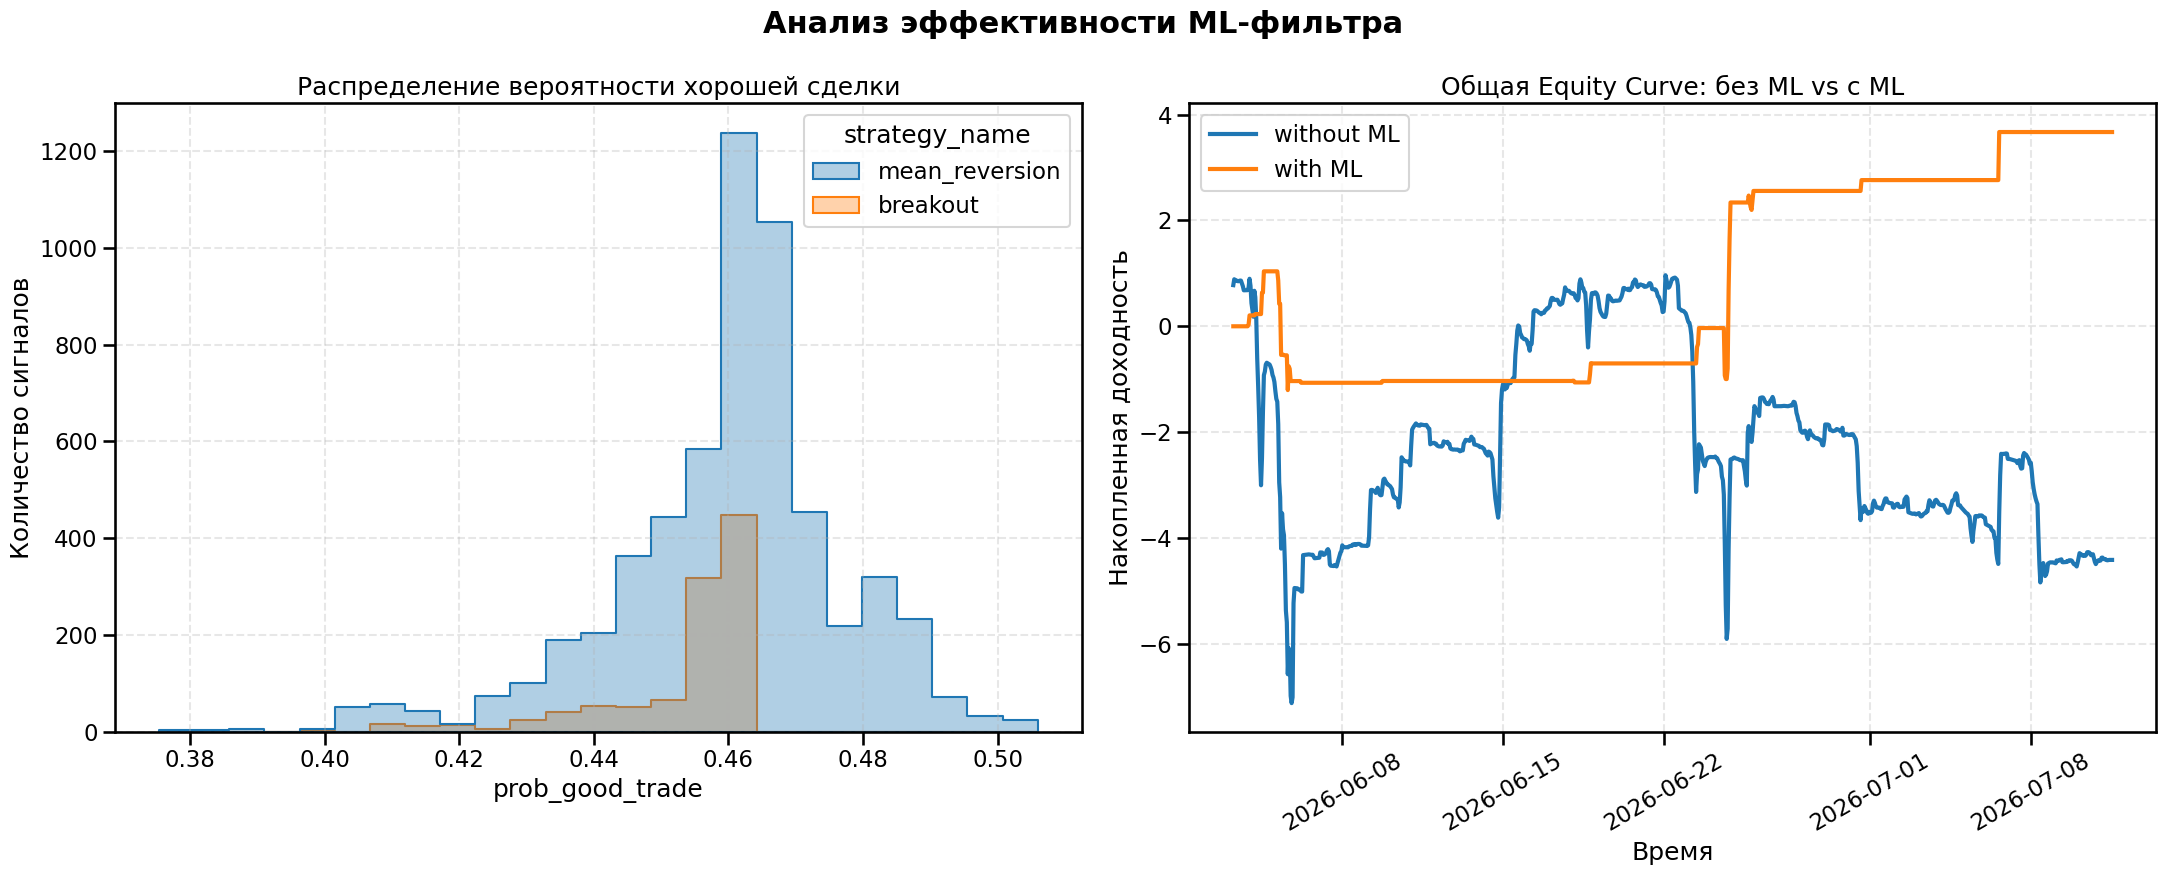

In [42]:
threshold = best_threshold 
test["prob_good_trade"] = model.predict_proba(predict_pool)[:, 1]
test["risk_score"] = 1 - test["prob_good_trade"]
test["trade_allowed"] = (test["prob_good_trade"] > threshold).astype(int)
test_res = test[["timestamp", "symbol", "strategy_name", "prob_good_trade", "risk_score", "target_good_trade", "trade_allowed"]]
display(test_res["trade_allowed"].value_counts())
display(test_res)

plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
sns.set_context("talk")

test_res = test.copy()
test_res["timestamp"] = pd.to_datetime(test_res["timestamp"])
test_res = test_res.sort_values("timestamp")

# доходность без фильтра
test_res["return_without_ml"] = test_res["net_return"]

# доходность с ML-фильтром
test_res["return_with_ml"] = test_res["net_return"] * test_res["trade_allowed"]

# общий equity по всем стратегиям
equity_total = (
    test_res
    .groupby("timestamp", as_index=False)[["return_without_ml", "return_with_ml"]]
    .sum()
    .sort_values("timestamp")
)

equity_total["equity_without_ml"] = equity_total["return_without_ml"].cumsum()
equity_total["equity_with_ml"] = equity_total["return_with_ml"].cumsum()

# equity отдельно по стратегиям
equity_by_strategy = (
    test_res
    .groupby(["strategy_name", "timestamp"], as_index=False)[
        ["return_without_ml", "return_with_ml"]
    ]
    .sum()
    .sort_values(["strategy_name", "timestamp"])
)

equity_by_strategy["equity_without_ml"] = (
    equity_by_strategy
    .groupby("strategy_name")["return_without_ml"]
    .cumsum()
)

equity_by_strategy["equity_with_ml"] = (
    equity_by_strategy
    .groupby("strategy_name")["return_with_ml"]
    .cumsum()
)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

fig.suptitle(
    "Анализ эффективности ML-фильтра",
    fontsize=22,
    fontweight="bold",
    y=0.98,
)

# распределение вероятностей
sns.histplot(
    data=test_res,
    x="prob_good_trade",
    hue="strategy_name",
    bins=25,
    element="step",
    common_norm=False,
    alpha=0.35,
    ax=axes[0],
)

axes[0].set_title("Распределение вероятности хорошей сделки")
axes[0].set_xlabel("prob_good_trade")
axes[0].set_ylabel("Количество сигналов")
axes[0].grid(True, alpha=0.3, linestyle="--")

# общий equity без ML и с ML
axes[1].plot(
    equity_total["timestamp"],
    equity_total["equity_without_ml"],
    label="without ML",
    linewidth=3,
)

axes[1].plot(
    equity_total["timestamp"],
    equity_total["equity_with_ml"],
    label="with ML",
    linewidth=3,
)

axes[1].set_title("Общая Equity Curve: без ML vs с ML")
axes[1].set_xlabel("Время")
axes[1].set_ylabel("Накопленная доходность")
axes[1].legend()
axes[1].grid(True, alpha=0.3, linestyle="--")

axes[1].xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=8))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

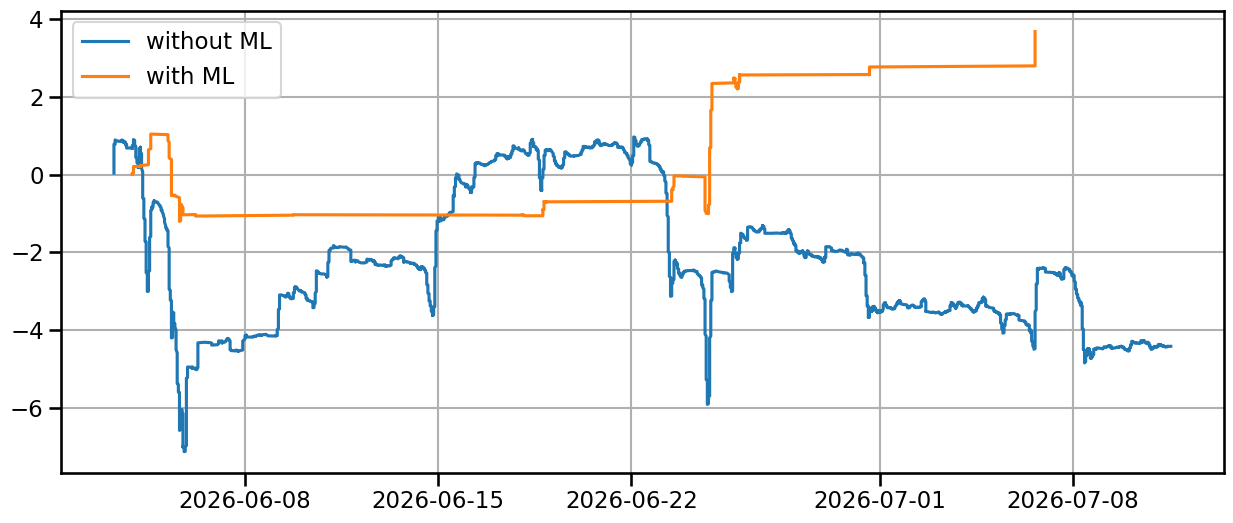

In [43]:
plot_all = test.sort_values("timestamp").copy()
plot_all["equity_without_ml"] = plot_all["net_return"].cumsum()

plot_ml = test[test["trade_allowed"] == 1].sort_values("timestamp").copy()
plot_ml["equity_with_ml"] = plot_ml["net_return"].cumsum()

plt.figure(figsize=(15, 6))
plt.plot(plot_all["timestamp"], plot_all["equity_without_ml"], label="without ML")
plt.plot(plot_ml["timestamp"], plot_ml["equity_with_ml"], label="with ML")
plt.legend()
plt.grid()
plt.show()

In [44]:
without_ml = test.copy()
with_ml = test[test["trade_allowed"] == 1].copy()

print("без ML:")
print("trades:", len(without_ml))
print("mean_return:", without_ml["net_return"].mean())
print("winrate:", (without_ml["net_return"] > 0).mean())
print("total_return:", without_ml["net_return"].sum())

print()

print("с ML:")
print("trades:", len(with_ml))
print("mean_return:", with_ml["net_return"].mean())
print("winrate:", (with_ml["net_return"] > 0).mean())
print("total_return:", with_ml["net_return"].sum())

без ML:
trades: 6839
mean_return: -0.0006458295322140289
winrate: 0.45840035092849835
total_return: -4.416828170811744

с ML:
trades: 678
mean_return: 0.00541686319713243
winrate: 0.6769911504424779
total_return: 3.6726332476557877


In [45]:
project_root = Path.cwd().parents[2]

models_dir = project_root / "ml_services" / "app" / "models"
models_dir.mkdir(parents=True, exist_ok=True)

model_name = "risk_model_v1_11072026"

model_path = models_dir / f"{model_name}.cbm"
config_path = models_dir / f"{model_name}_config.json"

model.save_model(str(model_path))

model_config = {
    "threshold": float(best_threshold),
    "feature_cols": feature_cols,
    "cat_features": cat_features,
}

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(model_config, f, ensure_ascii=False, indent=4)

print("saved model:", model_path.resolve())
print("saved config:", config_path.resolve())
print(list(models_dir.iterdir()))

saved model: C:\dany\vscode\python\pyproj\my\Trading_Risk_manager\app\ml_services\app\models\risk_model_v1_11072026.cbm
saved config: C:\dany\vscode\python\pyproj\my\Trading_Risk_manager\app\ml_services\app\models\risk_model_v1_11072026_config.json
[WindowsPath('c:/dany/vscode/python/pyproj/my/Trading_Risk_manager/app/ml_services/app/models/risk_model_v1_06072026.cbm'), WindowsPath('c:/dany/vscode/python/pyproj/my/Trading_Risk_manager/app/ml_services/app/models/risk_model_v1_06072026_config.json'), WindowsPath('c:/dany/vscode/python/pyproj/my/Trading_Risk_manager/app/ml_services/app/models/risk_model_v1_11072026.cbm'), WindowsPath('c:/dany/vscode/python/pyproj/my/Trading_Risk_manager/app/ml_services/app/models/risk_model_v1_11072026_config.json')]


## Проверки

In [22]:
feature_cols = list(dict.fromkeys(feature_cols))

cat_features = ["symbol", "strategy_name"]

train_days = 30
valid_days = 7
test_days = 7

min_train_size = 500
min_valid_size = 100
min_test_size = 100

all_test_results = []
window_stats = []

start_date = ml["timestamp"].min()
end_date = ml["timestamp"].max()

window_start = start_date

window_id = 0

while True:
    train_start = window_start
    train_end = train_start + pd.Timedelta(days=train_days)

    valid_start = train_end
    valid_end = valid_start + pd.Timedelta(days=valid_days)

    test_start = valid_end
    test_end = test_start + pd.Timedelta(days=test_days)

    if test_end > end_date:
        break

    train = ml[
        (ml["timestamp"] >= train_start) &
        (ml["timestamp"] < train_end)
    ].copy()

    valid = ml[
        (ml["timestamp"] >= valid_start) &
        (ml["timestamp"] < valid_end)
    ].copy()

    test = ml[
        (ml["timestamp"] >= test_start) &
        (ml["timestamp"] < test_end)
    ].copy()

    if len(train) < min_train_size or len(valid) < min_valid_size or len(test) < min_test_size:
        window_start += pd.Timedelta(days=test_days)
        continue

    if train["target_good_trade"].nunique() < 2:
        window_start += pd.Timedelta(days=test_days)
        continue

    X_train = train[feature_cols].copy()
    y_train = train["target_good_trade"]

    X_valid = valid[feature_cols].copy()
    y_valid = valid["target_good_trade"]

    X_test = test[feature_cols].copy()
    y_test = test["target_good_trade"]

    train_pool = Pool(
        data=X_train,
        label=y_train,
        cat_features=cat_features
    )

    valid_pool = Pool(
        data=X_valid,
        label=y_valid,
        cat_features=cat_features
    )

    test_pool = Pool(
        data=X_test,
        label=y_test,
        cat_features=cat_features
    )

    model = CatBoostClassifier(
        iterations=300,
        learning_rate=0.04,
        depth=4,
        loss_function="Logloss",
        eval_metric="AUC",
        verbose=False,
        random_seed=42
    )

    model.fit(
        train_pool,
        eval_set=valid_pool,
        early_stopping_rounds=50,
        use_best_model=True
    )

    # подбираем threshold только на valid
    valid_res = valid.copy()
    valid_res["prob_good_trade"] = model.predict_proba(valid_pool)[:, 1]

    threshold_rows = []

    for threshold in np.arange(0.30, 0.61, 0.01):
        tmp = valid_res[valid_res["prob_good_trade"] >= threshold]

        if len(tmp) < 30:
            continue

        threshold_rows.append({
            "threshold": threshold,
            "trades": len(tmp),
            "mean_return": tmp["net_return"].mean(),
            "winrate": (tmp["net_return"] > 0).mean(),
            "total_return": tmp["net_return"].sum(),
        })

    if len(threshold_rows) == 0:
        window_start += pd.Timedelta(days=test_days)
        continue

    threshold_table = pd.DataFrame(threshold_rows)

    best_threshold = (
        threshold_table
        .sort_values("total_return", ascending=False)
        .iloc[0]["threshold"]
    )

    # проверяем на test
    test_res = test.copy()
    test_res["prob_good_trade"] = model.predict_proba(test_pool)[:, 1]
    test_res["risk_score"] = 1 - test_res["prob_good_trade"]

    test_res["trade_allowed"] = (
        test_res["prob_good_trade"] >= best_threshold
    ).astype(int)

    without_ml = test_res.copy()
    with_ml = test_res[test_res["trade_allowed"] == 1].copy()

    total_without_ml = without_ml["net_return"].sum()
    total_with_ml = with_ml["net_return"].sum()

    stats = {
        "window_id": window_id,
        "train_start": train_start,
        "train_end": train_end,
        "valid_start": valid_start,
        "valid_end": valid_end,
        "test_start": test_start,
        "test_end": test_end,
        "threshold": best_threshold,

        "trades_without_ml": len(without_ml),
        "trades_with_ml": len(with_ml),

        "mean_return_without_ml": without_ml["net_return"].mean(),
        "mean_return_with_ml": with_ml["net_return"].mean(),

        "winrate_without_ml": (without_ml["net_return"] > 0).mean(),
        "winrate_with_ml": (with_ml["net_return"] > 0).mean(),

        "total_return_without_ml": total_without_ml,
        "total_return_with_ml": total_with_ml,

        "improvement": total_with_ml - total_without_ml,
        "model_best_iteration": model.get_best_iteration(),
    }

    window_stats.append(stats)

    test_res["window_id"] = window_id
    test_res["threshold"] = best_threshold

    all_test_results.append(test_res)

    print(
        f"window {window_id}: "
        f"without_ml={total_without_ml:.4f}, "
        f"with_ml={total_with_ml:.4f}, "
        f"improvement={total_with_ml - total_without_ml:.4f}, "
        f"threshold={best_threshold:.2f}"
    )

    window_id += 1
    window_start += pd.Timedelta(days=test_days)

window 0: without_ml=-3.1956, with_ml=-0.6137, improvement=2.5820, threshold=0.36
window 1: without_ml=-10.6221, with_ml=-6.4743, improvement=4.1478, threshold=0.49
window 2: without_ml=-19.9536, with_ml=-10.4683, improvement=9.4853, threshold=0.55
window 3: without_ml=2.3166, with_ml=0.0000, improvement=-2.3166, threshold=0.57
window 4: without_ml=-1.4905, with_ml=-1.3892, improvement=0.1013, threshold=0.30
window 5: without_ml=0.4983, with_ml=2.7784, improvement=2.2801, threshold=0.49
window 6: without_ml=-1.8452, with_ml=-1.2765, improvement=0.5687, threshold=0.46
window 7: without_ml=-2.8155, with_ml=-0.2410, improvement=2.5745, threshold=0.50
window 8: without_ml=-4.4005, with_ml=0.1984, improvement=4.5989, threshold=0.50
window 9: without_ml=-5.8045, with_ml=0.1610, improvement=5.9655, threshold=0.48
window 10: without_ml=-2.5079, with_ml=-1.4009, improvement=1.1070, threshold=0.43
window 11: without_ml=-2.6549, with_ml=0.0000, improvement=2.6549, threshold=0.59
window 12: withou

In [23]:
wf_stats = pd.DataFrame(window_stats)
test_res_wf = pd.concat(all_test_results, ignore_index=True)

wf_stats.head()


,window_id,train_start,train_end,valid_start,valid_end,test_start,test_end,threshold,trades_without_ml,trades_with_ml,mean_return_without_ml,mean_return_with_ml,winrate_without_ml,winrate_with_ml,total_return_without_ml,total_return_with_ml,improvement,model_best_iteration
0,0,2025-12-10 13:00:00,2026-01-09 13:00:00,2026-01-09 13:00:00,2026-01-16 13:00:00,2026-01-16 13:00:00,2026-01-23 13:00:00,0.36,1709,1058,-0.001870,-0.000580,0.410181,0.430057,-3.195649,-0.613685,2.581963,39
1,1,2025-12-17 13:00:00,2026-01-16 13:00:00,2026-01-16 13:00:00,2026-01-23 13:00:00,2026-01-23 13:00:00,2026-01-30 13:00:00,0.49,1905,1343,-0.005576,-0.004821,0.340157,0.379002,-10.622105,-6.474265,4.147840,1
2,2,2025-12-24 13:00:00,2026-01-23 13:00:00,2026-01-23 13:00:00,2026-01-30 13:00:00,2026-01-30 13:00:00,2026-02-06 13:00:00,0.55,2190,1649,-0.009111,-0.006348,0.368037,0.441480,-19.953586,-10.468314,9.485272,14
3,3,2025-12-31 13:00:00,2026-01-30 13:00:00,2026-01-30 13:00:00,2026-02-06 13:00:00,2026-02-06 13:00:00,2026-02-13 13:00:00,0.57,1214,0,0.001908,NaN,0.517298,NaN,2.316619,0.000000,-2.316619,18
4,4,2026-01-07 13:00:00,2026-02-06 13:00:00,2026-02-06 13:00:00,2026-02-13 13:00:00,2026-02-13 13:00:00,2026-02-20 13:00:00,0.30,1446,587,-0.001031,-0.002367,0.509682,0.534923,-1.490535,-1.389211,0.101324,148


количество окон: 25
доля окон, где ML улучшил результат:
0.88
суммарно без ML:
-79.81215435262169
суммарно с ML:
-14.468177850279034
суммарное улучшение:
65.34397650234266


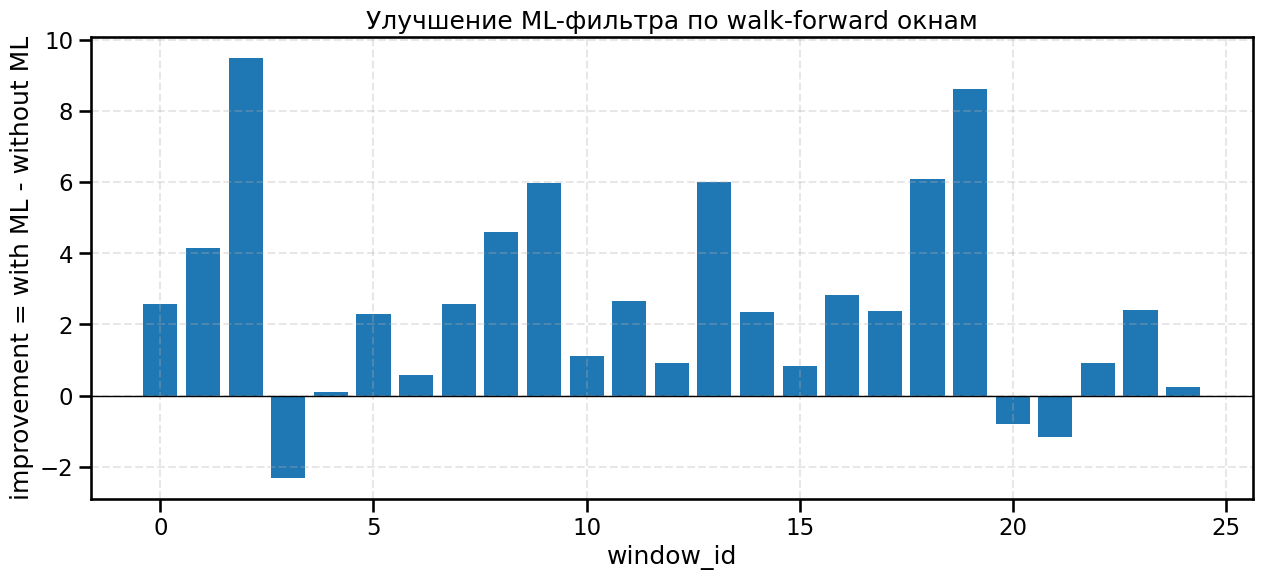

In [24]:
print("количество окон:", len(wf_stats))

print("доля окон, где ML улучшил результат:")
print((wf_stats["improvement"] > 0).mean())

print("суммарно без ML:")
print(wf_stats["total_return_without_ml"].sum())

print("суммарно с ML:")
print(wf_stats["total_return_with_ml"].sum())

print("суммарное улучшение:")
print(wf_stats["improvement"].sum())
wf_stats[[
    "window_id",
    "test_start",
    "test_end",
    "threshold",
    "trades_without_ml",
    "trades_with_ml",
    "winrate_without_ml",
    "winrate_with_ml",
    "total_return_without_ml",
    "total_return_with_ml",
    "improvement",
]]
plt.figure(figsize=(15, 6))

plt.bar(
    wf_stats["window_id"],
    wf_stats["improvement"]
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Улучшение ML-фильтра по walk-forward окнам")
plt.xlabel("window_id")
plt.ylabel("improvement = with ML - without ML")
plt.grid(True, alpha=0.3, linestyle="--")

plt.show()